In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [20]:
df = pd.read_csv("/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv", encoding="latin1")

print("First 5 Rows")
print(df.head())

print("\nShape:", df.shape)

print("\nColumns")
print(df.columns)

First 5 Rows
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0      

In [21]:
print("\nMissing Values")
print(df.isnull().sum())

# Remove missing values
df = df.dropna()

print("\nAfter Cleaning")
print(df.isnull().sum())


Missing Values
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

After Cleaning
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [22]:
# Convert date column
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Create Month column
df["Month"] = df["Order Date"].dt.month_name()

# Month order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

In [23]:
print("\nMean Sales")
print(df["Sales"].mean())
print("\nMedian Sales")
print(df["Sales"].median())


Mean Sales
229.85800083049833

Median Sales
54.489999999999995


In [24]:
print("\nMedian Sales")
print(df["Sales"].median())


Median Sales
54.489999999999995


In [25]:
print("\nMode Sales")
print(df["Sales"].mode())


Mode Sales
0    12.96
Name: Sales, dtype: float64


In [26]:
print(df["Sales"].describe())

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64


In [27]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


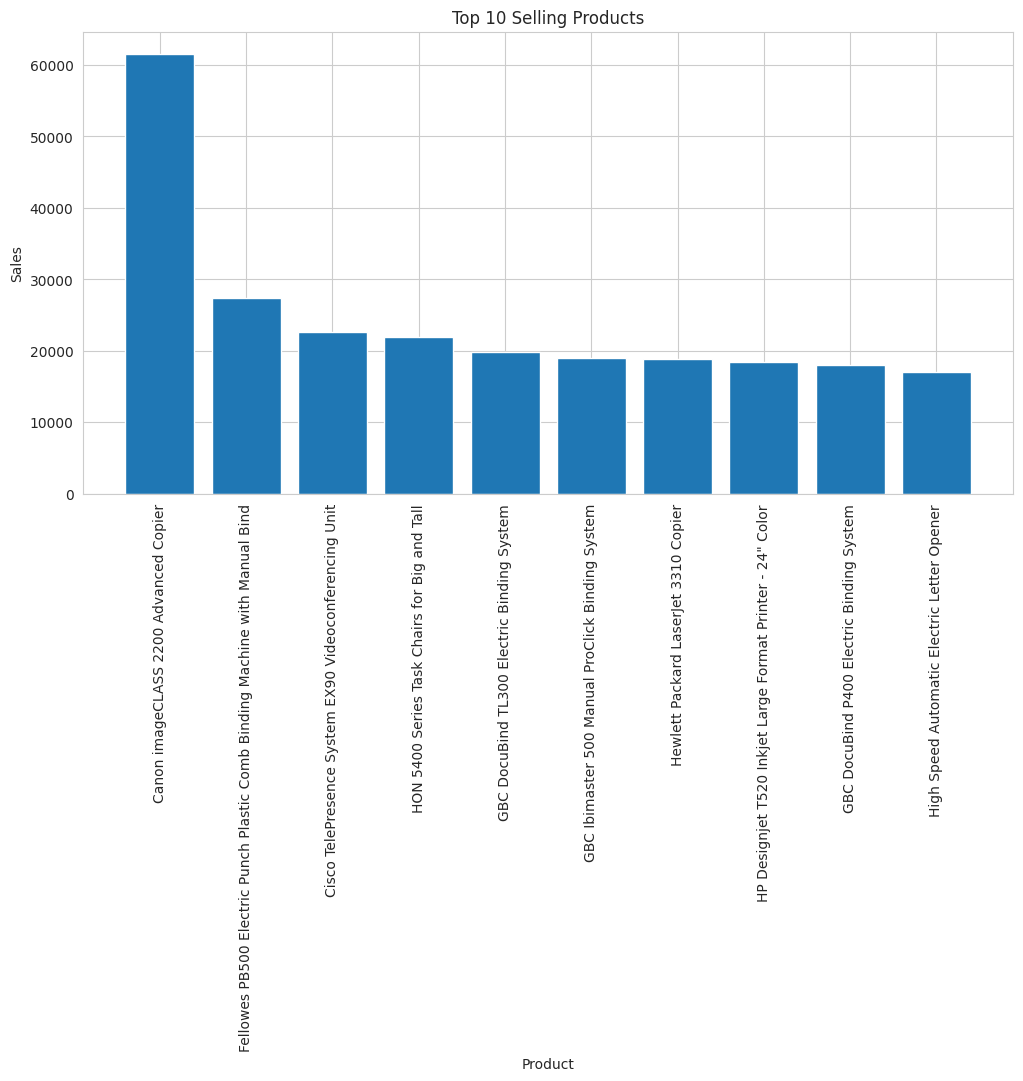

In [28]:
plt.figure(figsize=(12,6))

plt.bar(top_products.index,
        top_products.values)

plt.xticks(rotation=90)

plt.xlabel("Product")

plt.ylabel("Sales")

plt.title("Top 10 Selling Products")

plt.show()

In [29]:
monthly_sales = (
    df.groupby("Month")["Sales"]
    .sum()
    .reindex(month_order)
)

print(monthly_sales)

Month
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64


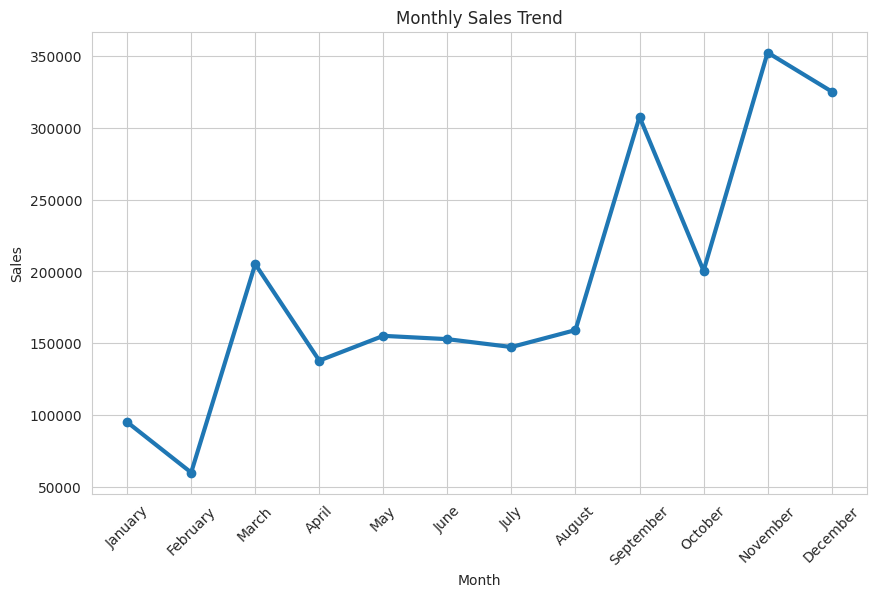

In [30]:
plt.figure(figsize=(10,6))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o',
         linewidth=3)

plt.xlabel("Month")

plt.ylabel("Sales")

plt.title("Monthly Sales Trend")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [31]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


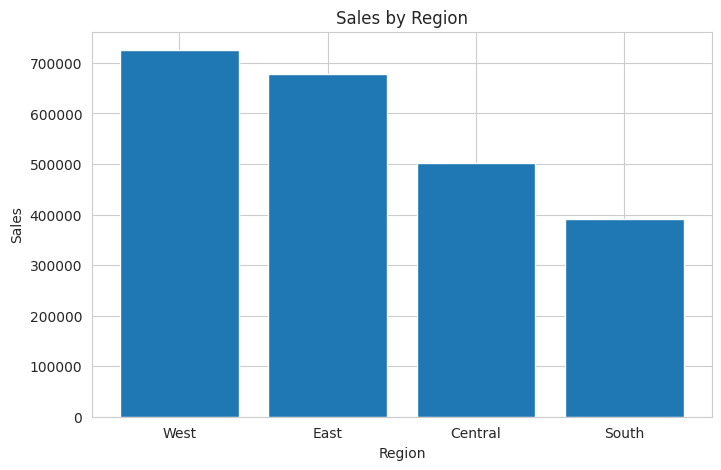

In [32]:
plt.figure(figsize=(8,5))

plt.bar(region_sales.index,
        region_sales.values)

plt.xlabel("Region")

plt.ylabel("Sales")

plt.title("Sales by Region")

plt.show()

In [33]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


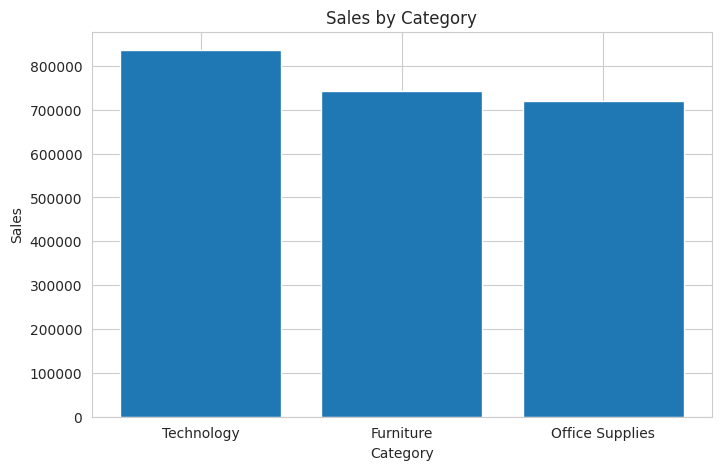

In [34]:
plt.figure(figsize=(8,5))

plt.bar(category_sales.index,
        category_sales.values)

plt.xlabel("Category")

plt.ylabel("Sales")

plt.title("Sales by Category")

plt.show()

In [35]:
top_regions = region_sales.head()

print(top_regions)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [36]:
top_categories = category_sales.head()

print(top_categories)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64
